# Event Impact Analyzer: Financial Sector

**How do bank stocks react to earnings surprises and analyst rating changes?**

This project analyzes 10 major financial stocks to answer:
1. When a company beats or misses earnings estimates, how does the stock price react over the following days?
2. When an analyst upgrades or downgrades a stock, does the market follow?
3. Can we predict the magnitude of price reaction from the size of the event?

**Data source:** Yahoo Finance via `yfinance` (free, no API key required)

**Stocks analyzed:** JPM, GS, BAC, WFC, MS, C, USB, PNC, SCHW, BK

## 1. Setup & Configuration

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import timedelta
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Financial sector tickers
TICKERS = ['JPM', 'GS', 'BAC', 'WFC', 'MS', 'C', 'USB', 'PNC', 'SCHW', 'BK']

# How many days before/after an event to track
WINDOW_BEFORE = 5
WINDOW_AFTER = 10

print(f"Analyzing {len(TICKERS)} financial stocks")
print(f"Event window: {WINDOW_BEFORE} days before to {WINDOW_AFTER} days after")

Analyzing 10 financial stocks
Event window: 5 days before to 10 days after


## 2. Data Collection

### 2.1 Earnings Surprise Data

We pull actual vs estimated EPS for each company. The **earnings surprise** is the percentage
difference between what analysts expected and what the company actually reported.
A positive surprise means the company beat expectations.

In [2]:
def get_earnings_data(tickers):
    """Pull earnings dates with actual vs estimated EPS for each ticker."""
    all_earnings = []
    
    for ticker_symbol in tickers:
        try:
            ticker = yf.Ticker(ticker_symbol)
            ed = ticker.earnings_dates
            
            if ed is not None and not ed.empty:
                df = ed.copy()
                df['Ticker'] = ticker_symbol
                df.index.name = 'Earnings Date'
                df = df.reset_index()
                
                # Keep only rows with actual reported data (drop future dates)
                df = df.dropna(subset=['Reported EPS'])
                all_earnings.append(df)
                print(f"  {ticker_symbol}: {len(df)} earnings events")
            else:
                print(f"  {ticker_symbol}: no earnings data")
        except Exception as e:
            print(f"  {ticker_symbol}: error - {e}")
    
    if all_earnings:
        result = pd.concat(all_earnings, ignore_index=True)
        print(f"\nTotal earnings events: {len(result)}")
        return result
    return pd.DataFrame()

print("Pulling earnings data...")
earnings_df = get_earnings_data(TICKERS)
earnings_df.head(10)

Pulling earnings data...
  JPM: 24 earnings events
  GS: 24 earnings events
  BAC: 24 earnings events
  WFC: 24 earnings events
  MS: 24 earnings events
  C: 24 earnings events
  USB: 24 earnings events
  PNC: 24 earnings events
  SCHW: 24 earnings events
  BK: 24 earnings events

Total earnings events: 240


,Earnings Date,EPS Estimate,Reported EPS,Surprise(%),Ticker
0,2026-01-13 06:00:00-05:00,4.82,4.63,-3.91,JPM
1,2025-10-14 06:00:00-04:00,4.87,5.07,4.01,JPM
2,2025-07-15 06:00:00-04:00,4.47,4.96,10.89,JPM
3,2025-04-11 06:00:00-04:00,4.64,5.07,9.15,JPM
4,2025-01-15 06:00:00-05:00,4.04,4.81,19.18,JPM
5,2024-10-11 06:00:00-04:00,3.99,4.37,9.63,JPM
6,2024-07-12 06:00:00-04:00,4.53,6.12,35.02,JPM
7,2024-04-12 06:00:00-04:00,4.13,4.44,7.40,JPM
8,2024-01-12 06:00:00-05:00,3.60,3.04,-15.65,JPM
9,2023-10-13 06:00:00-04:00,3.97,4.33,9.01,JPM


### 2.2 Historical Price Data

In [3]:
def get_price_data(tickers, start='2019-01-01'):
    """Pull daily price history for all tickers."""
    print(f"Downloading price data from {start}...")
    prices = yf.download(tickers, start=start, auto_adjust=True, progress=True)
    
    # yf.download returns MultiIndex columns for multiple tickers
    # Extract just the Close prices
    if isinstance(prices.columns, pd.MultiIndex):
        close = prices['Close']
    else:
        close = prices[['Close']]
    
    # Flatten column names if needed
    if isinstance(close.columns, pd.MultiIndex):
        close.columns = close.columns.get_level_values(-1)
    
    print(f"Price data shape: {close.shape}")
    print(f"Date range: {close.index.min().date()} to {close.index.max().date()}")
    return close

close_prices = get_price_data(TICKERS)
close_prices.tail()

[*********************100%***********************]  10 of 10 completed

Price data shape: (1814, 10)
Date range: 2019-01-02 to 2026-03-20


Ticker,BAC,BK,C,GS,JPM,MS,PNC,SCHW,USB,WFC
Date,,,,,,,,,,
2026-03-16,47.060001,115.379997,107.349998,794.770020,286.160004,155.699997,200.750000,93.629997,51.160000,75.750000
2026-03-17,47.279999,116.120003,107.709999,807.039978,286.890015,157.830002,203.919998,93.930000,51.580002,76.230003
2026-03-18,46.830002,114.660004,108.669998,805.479980,287.739990,158.929993,201.169998,93.279999,51.320000,76.190002
2026-03-19,47.009998,114.900002,109.849998,809.500000,287.970001,158.550003,202.050003,93.989998,51.299999,76.389999
2026-03-20,47.160000,114.940002,109.519997,813.530029,286.559998,161.470001,201.710007,94.660004,51.250000,77.599998


### 2.3 Analyst Upgrades & Downgrades

In [4]:
def get_analyst_actions(tickers):
    """Pull analyst upgrade/downgrade history for each ticker."""
    all_actions = []
    
    for ticker_symbol in tickers:
        try:
            ticker = yf.Ticker(ticker_symbol)
            ud = ticker.upgrades_downgrades
            
            if ud is not None and not ud.empty:
                df = ud.copy()
                df['Ticker'] = ticker_symbol
                df.index.name = 'Date'
                df = df.reset_index()
                all_actions.append(df)
                print(f"  {ticker_symbol}: {len(df)} analyst actions")
            else:
                print(f"  {ticker_symbol}: no analyst data")
        except Exception as e:
            print(f"  {ticker_symbol}: error - {e}")
    
    if all_actions:
        result = pd.concat(all_actions, ignore_index=True)
        print(f"\nTotal analyst actions: {len(result)}")
        return result
    return pd.DataFrame()

print("Pulling analyst data...")
analyst_df = get_analyst_actions(TICKERS)
analyst_df.head(10)

Pulling analyst data...
  JPM: 415 analyst actions
  GS: 406 analyst actions
  BAC: 390 analyst actions
  WFC: 519 analyst actions
  MS: 337 analyst actions
  C: 206 analyst actions
  USB: 462 analyst actions
  PNC: 348 analyst actions
  SCHW: 477 analyst actions
  BK: 327 analyst actions

Total analyst actions: 3887


,Date,Firm,ToGrade,FromGrade,Action,priceTargetAction,currentPriceTarget,priorPriceTarget,Ticker
0,2026-02-17 14:15:44,Wells Fargo,Overweight,Overweight,main,Lowers,350.0,360.0,JPM
1,2026-01-14 13:02:10,CICC,Outperform,,init,Announces,355.0,0.0,JPM
2,2026-01-06 15:03:11,Truist Securities,Hold,Hold,main,Raises,331.0,330.0,JPM
3,2026-01-05 14:46:17,Barclays,Overweight,Overweight,main,Raises,391.0,342.0,JPM
4,2025-12-18 14:29:56,Truist Securities,Hold,Hold,main,Raises,330.0,319.0,JPM
5,2025-12-17 18:05:25,"Keefe, Bruyette & Woods",Outperform,Outperform,main,Raises,363.0,354.0,JPM
6,2025-11-03 14:08:49,Wells Fargo,Overweight,Overweight,main,Raises,350.0,345.0,JPM
7,2025-10-15 14:45:33,Barclays,Overweight,Overweight,main,Raises,342.0,330.0,JPM
8,2025-10-15 13:04:40,Morgan Stanley,Equal-Weight,Equal-Weight,main,Raises,338.0,336.0,JPM
9,2025-10-07 16:36:17,UBS,Buy,Buy,main,Raises,350.0,339.0,JPM


## 3. Earnings Impact Analysis

For each earnings event, we measure the stock's daily return in a window around the announcement.
This is called an **event study**, a standard methodology in finance research.

In [5]:
def calculate_event_returns(events_df, date_col, ticker_col, close_prices, 
                           window_before=5, window_after=10):
    """
    For each event, calculate daily returns in a window around the event date.
    Returns a DataFrame with columns for each day relative to the event (day -5 to +10).
    """
    results = []
    
    for _, event in events_df.iterrows():
        ticker = event[ticker_col]
        event_date = pd.Timestamp(event[date_col])
        
        # Make event_date timezone-naive to match price index
        if event_date.tzinfo is not None:
            event_date = event_date.tz_localize(None)
        
        if ticker not in close_prices.columns:
            continue
        
        # Get price series for this ticker
        prices = close_prices[ticker].dropna()
        
        # Also make price index timezone-naive
        if prices.index.tzinfo is not None:
            prices.index = prices.index.tz_localize(None)
        
        # Find the nearest trading day to the event date
        trading_days = prices.index
        future_days = trading_days[trading_days >= event_date.normalize()]
        
        if len(future_days) == 0:
            continue
        
        event_trading_day = future_days[0]
        event_idx = trading_days.get_loc(event_trading_day)
        
        # Get prices in the window
        start_idx = max(0, event_idx - window_before)
        end_idx = min(len(trading_days) - 1, event_idx + window_after)
        
        if event_idx - start_idx < window_before:
            continue  # Not enough history before event
        
        window_prices = prices.iloc[start_idx:end_idx + 1]
        
        # Calculate returns relative to the day before the event
        pre_event_price = prices.iloc[event_idx - 1]
        cumulative_returns = (window_prices / pre_event_price - 1) * 100
        
        # Create a row with day-relative returns
        row = event.to_dict()
        for i, (date, ret) in enumerate(cumulative_returns.items()):
            day_relative = i - window_before
            row[f'Day_{day_relative}'] = ret
        
        results.append(row)
    
    return pd.DataFrame(results)

# Calculate returns around earnings events
print("Calculating price reactions around earnings announcements...")
earnings_returns = calculate_event_returns(
    earnings_df, 'Earnings Date', 'Ticker', close_prices,
    WINDOW_BEFORE, WINDOW_AFTER
)
print(f"Successfully matched {len(earnings_returns)} earnings events with price data")

Calculating price reactions around earnings announcements...
Successfully matched 240 earnings events with price data


### 3.1 Do Earnings Beats Lead to Price Increases?

In [6]:
# Classify events as beats, misses, or in-line
earnings_returns['Category'] = pd.cut(
    earnings_returns['Surprise(%)'],
    bins=[-np.inf, -2, 2, np.inf],
    labels=['Miss (< -2%)', 'In-Line (-2% to 2%)', 'Beat (> 2%)']
)

print("Event distribution:")
print(earnings_returns['Category'].value_counts())
print(f"\nAverage surprise: {earnings_returns['Surprise(%)'].mean():.2f}%")
print(f"Median surprise:  {earnings_returns['Surprise(%)'].median():.2f}%")

Event distribution:
Category
Beat (> 2%)            179
Miss (< -2%)            44
In-Line (-2% to 2%)     17
Name: count, dtype: int64

Average surprise: 8.61%
Median surprise:  8.06%


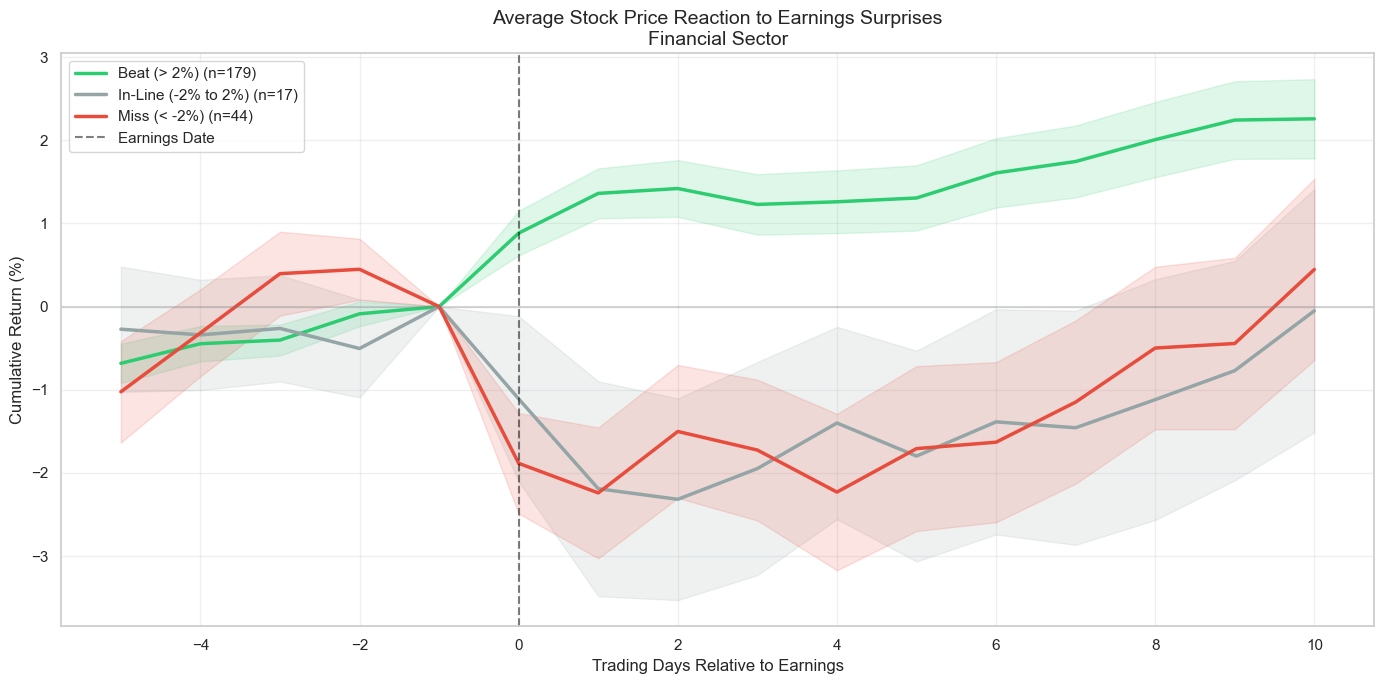

Chart saved: earnings_reaction_curve.png


In [7]:
# Plot average cumulative returns for beats vs misses
day_columns = [c for c in earnings_returns.columns if c.startswith('Day_')]
day_numbers = [int(c.split('_')[1]) for c in day_columns]

fig, ax = plt.subplots(figsize=(14, 7))

colors = {'Beat (> 2%)': '#2ecc71', 'In-Line (-2% to 2%)': '#95a5a6', 'Miss (< -2%)': '#e74c3c'}

for category in ['Beat (> 2%)', 'In-Line (-2% to 2%)', 'Miss (< -2%)']:
    subset = earnings_returns[earnings_returns['Category'] == category]
    if len(subset) == 0:
        continue
    
    means = subset[day_columns].mean()
    stds = subset[day_columns].std() / np.sqrt(len(subset))  # Standard error
    
    ax.plot(day_numbers, means.values, label=f'{category} (n={len(subset)})', 
            color=colors[category], linewidth=2.5)
    ax.fill_between(day_numbers, 
                    (means - stds).values, 
                    (means + stds).values,
                    color=colors[category], alpha=0.15)

ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Earnings Date')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Trading Days Relative to Earnings', fontsize=12)
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.set_title('Average Stock Price Reaction to Earnings Surprises\nFinancial Sector', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('earnings_reaction_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: earnings_reaction_curve.png")

### 3.2 Does the Size of the Surprise Predict the Price Move?

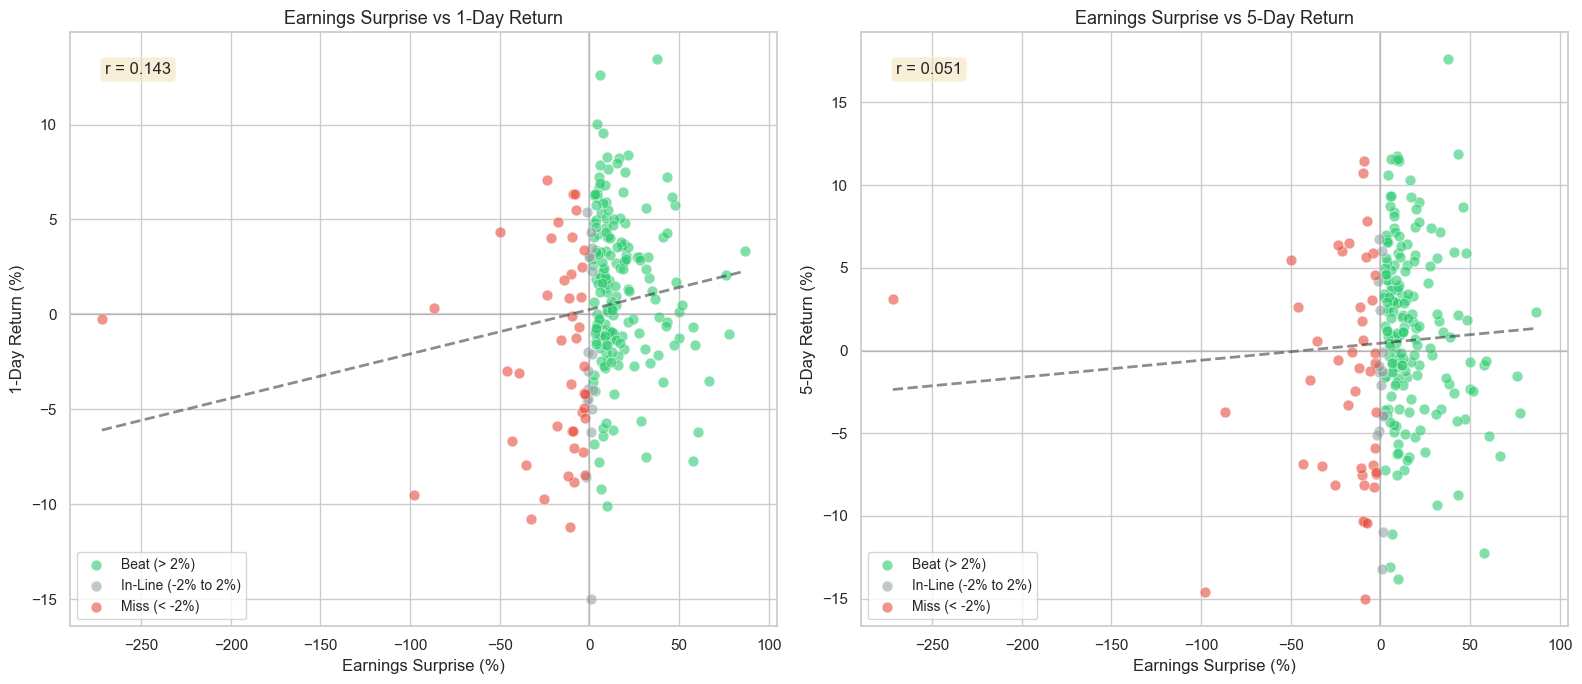

Chart saved: earnings_surprise_scatter.png


In [8]:
# Scatter plot: surprise magnitude vs 1-day and 5-day returns
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, (day_col, label) in enumerate([('Day_1', '1-Day Return'), ('Day_5', '5-Day Return')]):
    if day_col not in earnings_returns.columns:
        continue
    
    ax = axes[i]
    
    # Color by category
    for category, color in colors.items():
        subset = earnings_returns[earnings_returns['Category'] == category]
        ax.scatter(subset['Surprise(%)'], subset[day_col], 
                  color=color, alpha=0.6, s=60, label=category, edgecolors='white', linewidth=0.5)
    
    # Add trend line
    mask = earnings_returns[['Surprise(%)', day_col]].dropna().index
    x = earnings_returns.loc[mask, 'Surprise(%)']
    y = earnings_returns.loc[mask, day_col]
    
    if len(x) > 2:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, p(x_line), 'k--', alpha=0.5, linewidth=2)
        
        # Correlation
        corr = x.corr(y)
        ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, 
                fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
    ax.set_xlabel('Earnings Surprise (%)', fontsize=12)
    ax.set_ylabel(f'{label} (%)', fontsize=12)
    ax.set_title(f'Earnings Surprise vs {label}', fontsize=13)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('earnings_surprise_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: earnings_surprise_scatter.png")

### 3.3 Earnings Impact by Company

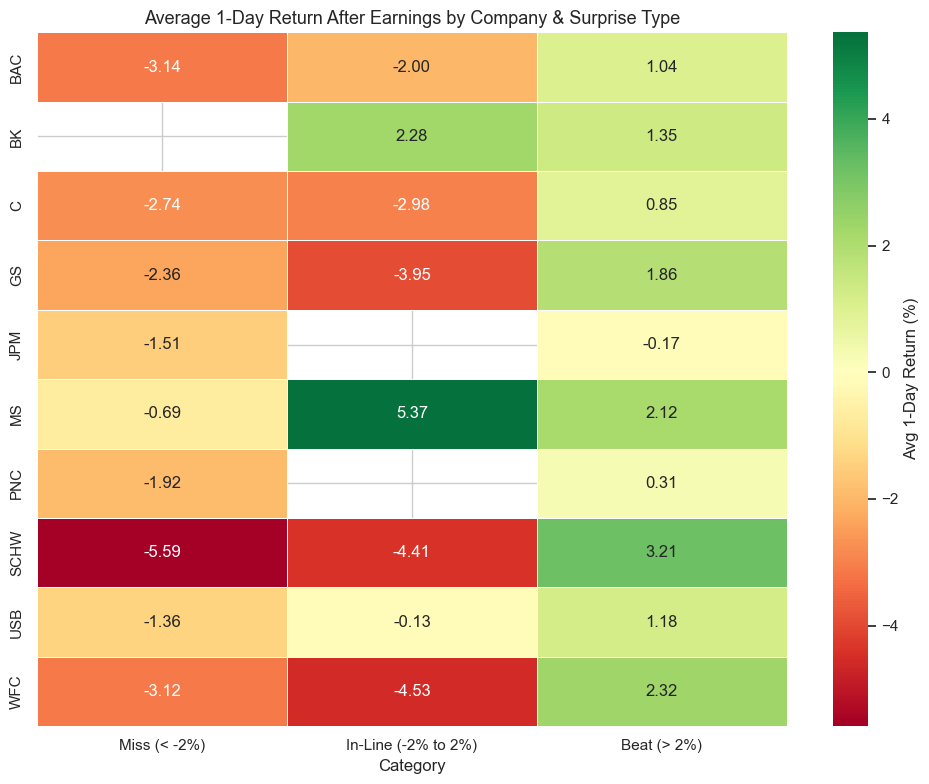

Chart saved: earnings_heatmap.png


In [9]:
# Heatmap: average 1-day return after earnings by company and surprise category
if 'Day_1' in earnings_returns.columns:
    pivot = earnings_returns.pivot_table(
        values='Day_1', 
        index='Ticker', 
        columns='Category', 
        aggfunc='mean'
    )
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Avg 1-Day Return (%)'})
    ax.set_title('Average 1-Day Return After Earnings by Company & Surprise Type', fontsize=13)
    ax.set_ylabel('')
    
    plt.tight_layout()
    plt.savefig('earnings_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved: earnings_heatmap.png")

## 4. Analyst Rating Impact Analysis

Now we look at the other major event type: when analysts upgrade or downgrade a stock.
We focus on clear directional actions (upgrades and downgrades) and measure the 
stock's reaction in the same event-study framework.

In [10]:
# Filter to just upgrades and downgrades
analyst_filtered = analyst_df[analyst_df['Action'].isin(['up', 'down'])].copy()
print(f"Upgrades: {(analyst_filtered['Action'] == 'up').sum()}")
print(f"Downgrades: {(analyst_filtered['Action'] == 'down').sum()}")

# Calculate returns around analyst actions
print("\nCalculating price reactions around analyst actions...")
analyst_returns = calculate_event_returns(
    analyst_filtered, 'Date', 'Ticker', close_prices,
    WINDOW_BEFORE, WINDOW_AFTER
)
print(f"Successfully matched {len(analyst_returns)} analyst actions with price data")

Upgrades: 449
Downgrades: 444

Calculating price reactions around analyst actions...
Successfully matched 451 analyst actions with price data


### 4.1 Average Price Reaction to Upgrades vs Downgrades

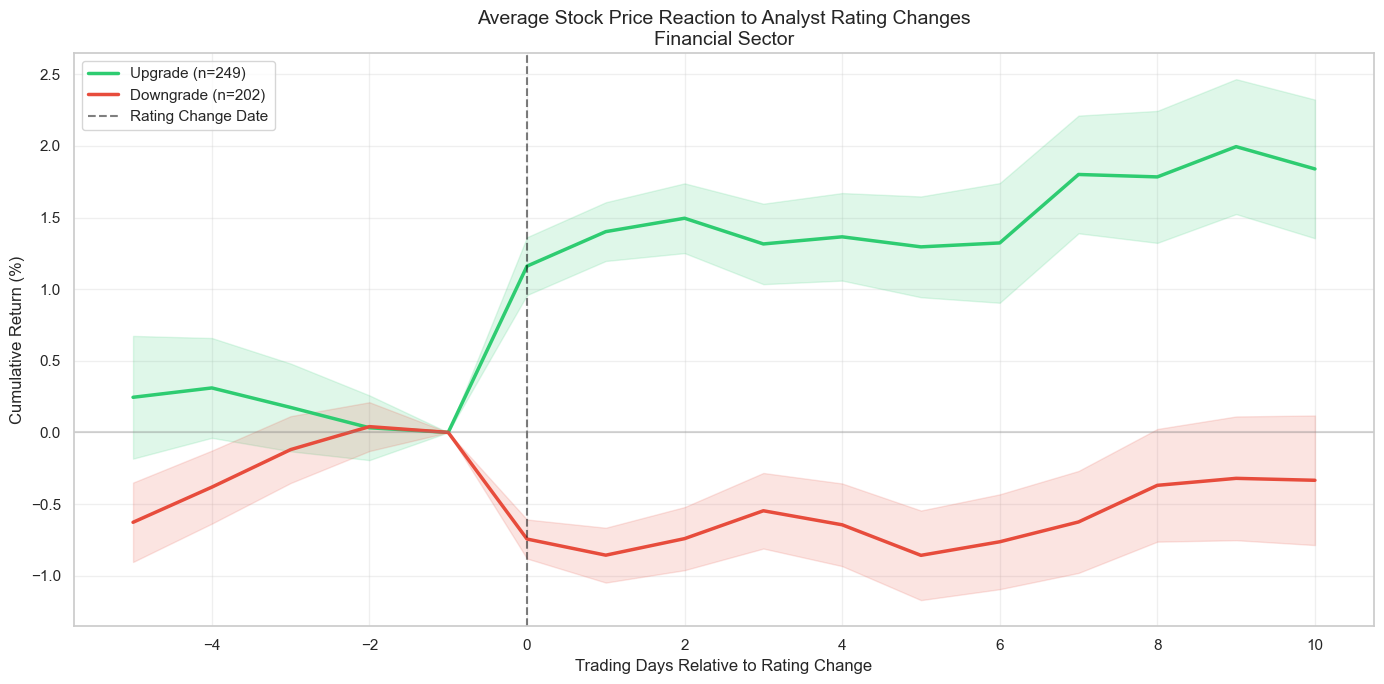

Chart saved: analyst_reaction_curve.png


In [11]:
fig, ax = plt.subplots(figsize=(14, 7))

action_colors = {'up': '#2ecc71', 'down': '#e74c3c'}
action_labels = {'up': 'Upgrade', 'down': 'Downgrade'}

for action in ['up', 'down']:
    subset = analyst_returns[analyst_returns['Action'] == action]
    if len(subset) == 0:
        continue
    
    means = subset[day_columns].mean()
    stds = subset[day_columns].std() / np.sqrt(len(subset))
    
    ax.plot(day_numbers, means.values, 
            label=f'{action_labels[action]} (n={len(subset)})',
            color=action_colors[action], linewidth=2.5)
    ax.fill_between(day_numbers,
                    (means - stds).values,
                    (means + stds).values,
                    color=action_colors[action], alpha=0.15)

ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Rating Change Date')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Trading Days Relative to Rating Change', fontsize=12)
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.set_title('Average Stock Price Reaction to Analyst Rating Changes\nFinancial Sector', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analyst_reaction_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: analyst_reaction_curve.png")

### 4.2 Which Analyst Firms Move the Market Most?

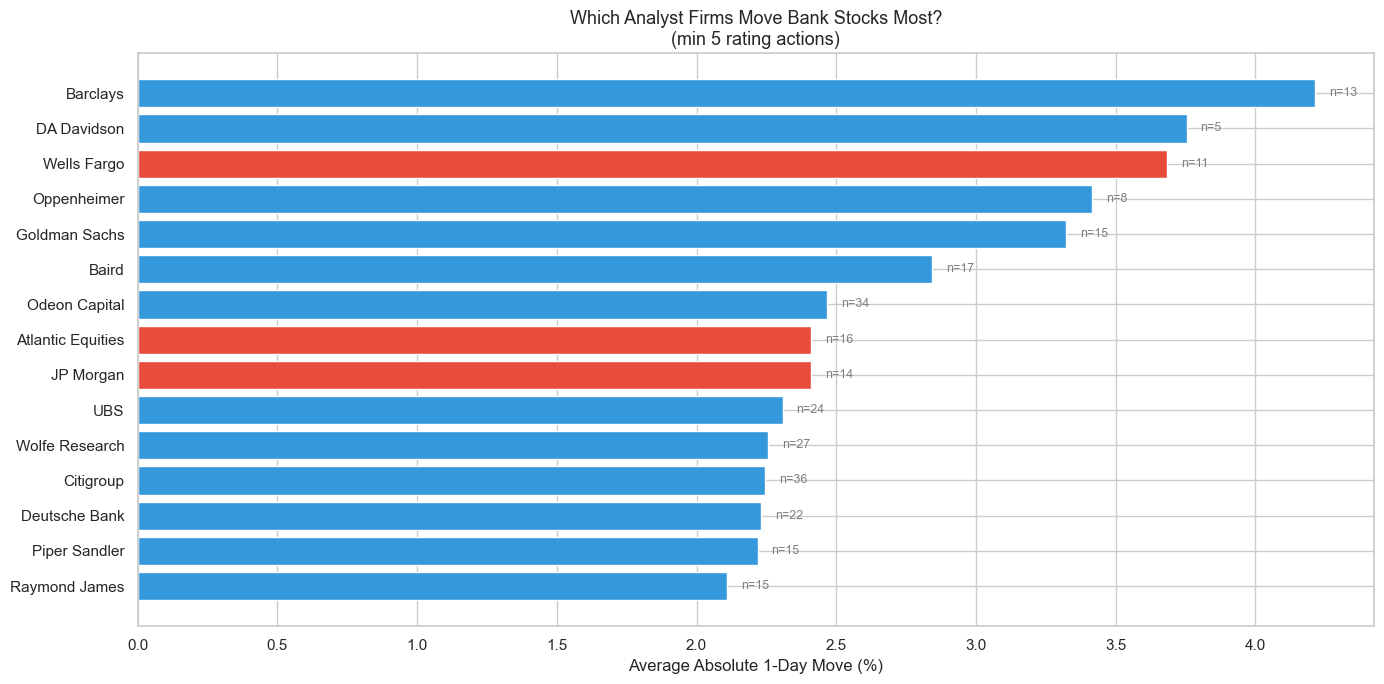

Chart saved: analyst_firm_impact.png


In [12]:
# Calculate average absolute 1-day return by analyst firm
if 'Day_1' in analyst_returns.columns:
    firm_impact = analyst_returns.groupby('Firm').agg(
        avg_move=('Day_1', lambda x: x.abs().mean()),
        num_actions=('Day_1', 'count'),
        avg_return=('Day_1', 'mean')
    ).sort_values('avg_move', ascending=False)
    
    # Filter to firms with at least 5 actions for statistical relevance
    firm_impact_filtered = firm_impact[firm_impact['num_actions'] >= 5].head(15)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    bars = ax.barh(range(len(firm_impact_filtered)), 
                   firm_impact_filtered['avg_move'],
                   color=['#3498db' if x >= 0 else '#e74c3c' 
                          for x in firm_impact_filtered['avg_return']])
    ax.set_yticks(range(len(firm_impact_filtered)))
    ax.set_yticklabels(firm_impact_filtered.index)
    ax.set_xlabel('Average Absolute 1-Day Move (%)', fontsize=12)
    ax.set_title('Which Analyst Firms Move Bank Stocks Most?\n(min 5 rating actions)', fontsize=13)
    ax.invert_yaxis()
    
    # Add count labels
    for i, (_, row) in enumerate(firm_impact_filtered.iterrows()):
        ax.text(row['avg_move'] + 0.05, i, f'n={int(row["num_actions"])}', 
                va='center', fontsize=9, color='gray')
    
    plt.tight_layout()
    plt.savefig('analyst_firm_impact.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved: analyst_firm_impact.png")

### 4.3 Price Target Changes: Do They Matter?

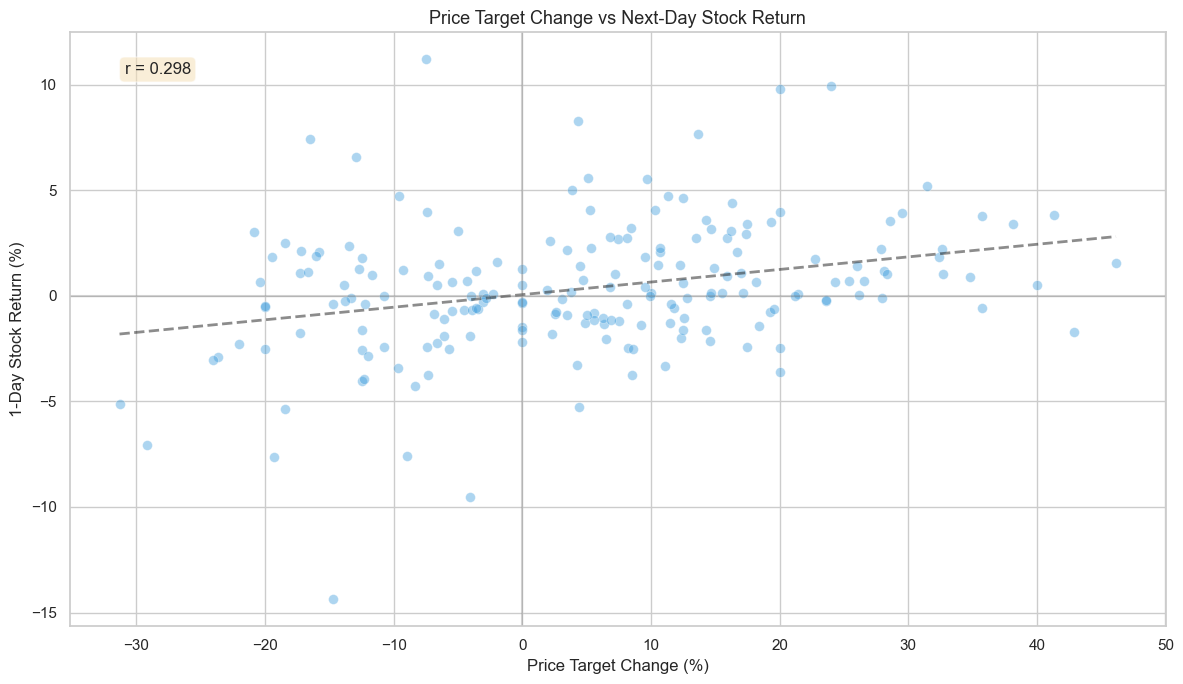

Chart saved: price_target_scatter.png


In [13]:
# Analyze price target changes and their predictive value
if 'currentPriceTarget' in analyst_returns.columns and 'priorPriceTarget' in analyst_returns.columns:
    at = analyst_returns.copy()
    at['PT_Change_Pct'] = ((at['currentPriceTarget'] - at['priorPriceTarget']) 
                           / at['priorPriceTarget'] * 100)
    
    # Drop rows where prior target was 0 or NaN
    at = at[(at['priorPriceTarget'] > 0) & at['PT_Change_Pct'].notna() & at['Day_1'].notna()]
    at = at[at['PT_Change_Pct'].between(-50, 50)]  # Remove outliers
    
    if len(at) > 5:
        fig, ax = plt.subplots(figsize=(12, 7))
        
        ax.scatter(at['PT_Change_Pct'], at['Day_1'], alpha=0.4, s=50, 
                  color='#3498db', edgecolors='white', linewidth=0.5)
        
        # Trend line
        z = np.polyfit(at['PT_Change_Pct'], at['Day_1'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(at['PT_Change_Pct'].min(), at['PT_Change_Pct'].max(), 100)
        ax.plot(x_line, p(x_line), 'k--', alpha=0.5, linewidth=2)
        
        corr = at['PT_Change_Pct'].corr(at['Day_1'])
        ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
                fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
        ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
        ax.set_xlabel('Price Target Change (%)', fontsize=12)
        ax.set_ylabel('1-Day Stock Return (%)', fontsize=12)
        ax.set_title('Price Target Change vs Next-Day Stock Return', fontsize=13)
        
        plt.tight_layout()
        plt.savefig('price_target_scatter.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Chart saved: price_target_scatter.png")
    else:
        print("Not enough price target data for analysis")
else:
    print("Price target columns not found in data")

## 5. Earnings vs Analyst Actions: Which Moves Stocks More?

Let's directly compare the average price impact of earnings surprises versus analyst
rating changes.

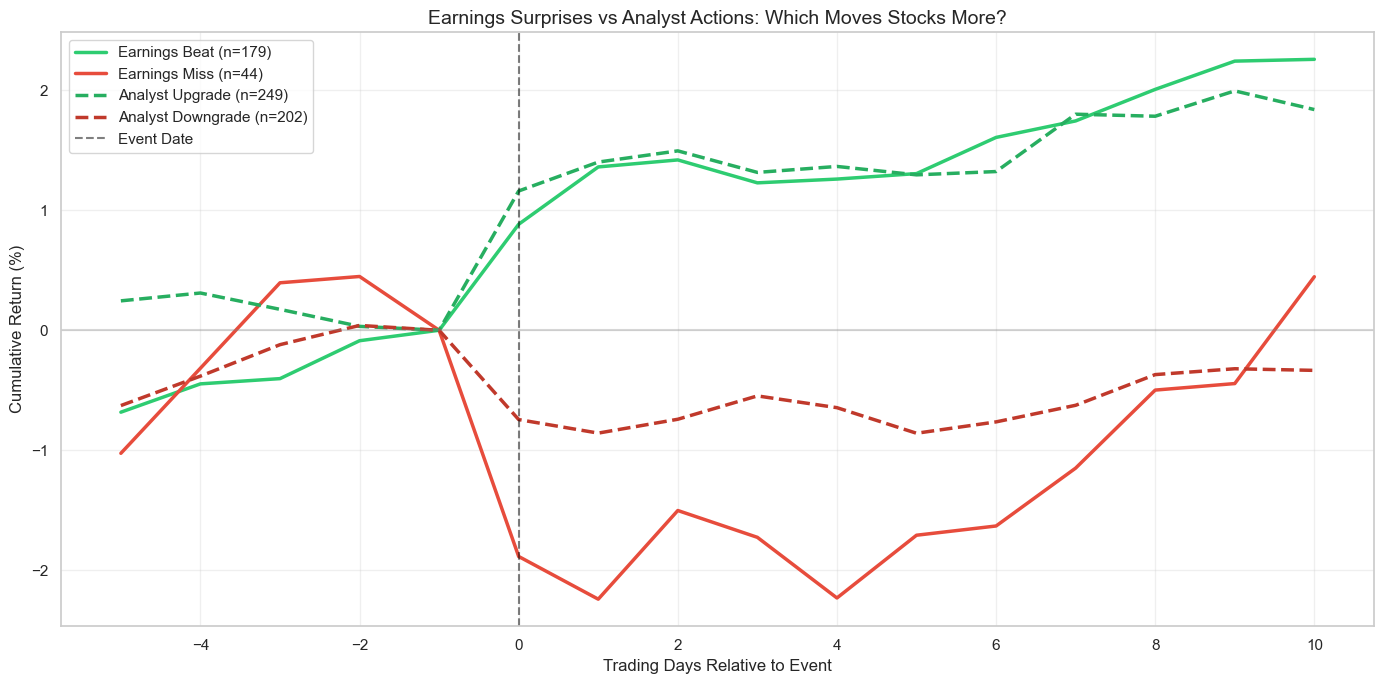

Chart saved: earnings_vs_analyst_comparison.png


In [14]:
fig, ax = plt.subplots(figsize=(14, 7))

plot_data = {}

# Earnings beats vs misses
for category in ['Beat (> 2%)', 'Miss (< -2%)']:
    subset = earnings_returns[earnings_returns['Category'] == category]
    if len(subset) > 0 and all(c in subset.columns for c in day_columns):
        plot_data[f'Earnings {category.split("(")[0].strip()}'] = {
            'means': subset[day_columns].mean(),
            'n': len(subset)
        }

# Analyst upgrades vs downgrades
for action, label in [('up', 'Analyst Upgrade'), ('down', 'Analyst Downgrade')]:
    subset = analyst_returns[analyst_returns['Action'] == action]
    if len(subset) > 0 and all(c in subset.columns for c in day_columns):
        plot_data[label] = {
            'means': subset[day_columns].mean(),
            'n': len(subset)
        }

line_styles = ['-', '-', '--', '--']
all_colors = ['#2ecc71', '#e74c3c', '#27ae60', '#c0392b']

for i, (label, data) in enumerate(plot_data.items()):
    ax.plot(day_numbers, data['means'].values,
            label=f'{label} (n={data["n"]})',
            linestyle=line_styles[i % len(line_styles)],
            color=all_colors[i % len(all_colors)],
            linewidth=2.5)

ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Event Date')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.set_xlabel('Trading Days Relative to Event', fontsize=12)
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.set_title('Earnings Surprises vs Analyst Actions: Which Moves Stocks More?', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('earnings_vs_analyst_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: earnings_vs_analyst_comparison.png")

## 6. Predictive Model

Can we predict the 1-day stock return after an earnings announcement using the 
earnings surprise percentage?

We use a simple linear regression as a baseline, then try a Random Forest to capture
any non-linear patterns.

MODEL RESULTS: Predicting 1-Day Return from Earnings Surprise

Sample size: 240 earnings events

Linear Regression:
  Coefficient: 0.0233 (a 1% surprise -> 0.0233% return)
  Intercept:   0.2481
  Cross-val R2: 0.0074 (+/- 0.0156)

Random Forest:
  Cross-val R2: 0.0256 (+/- 0.1155)


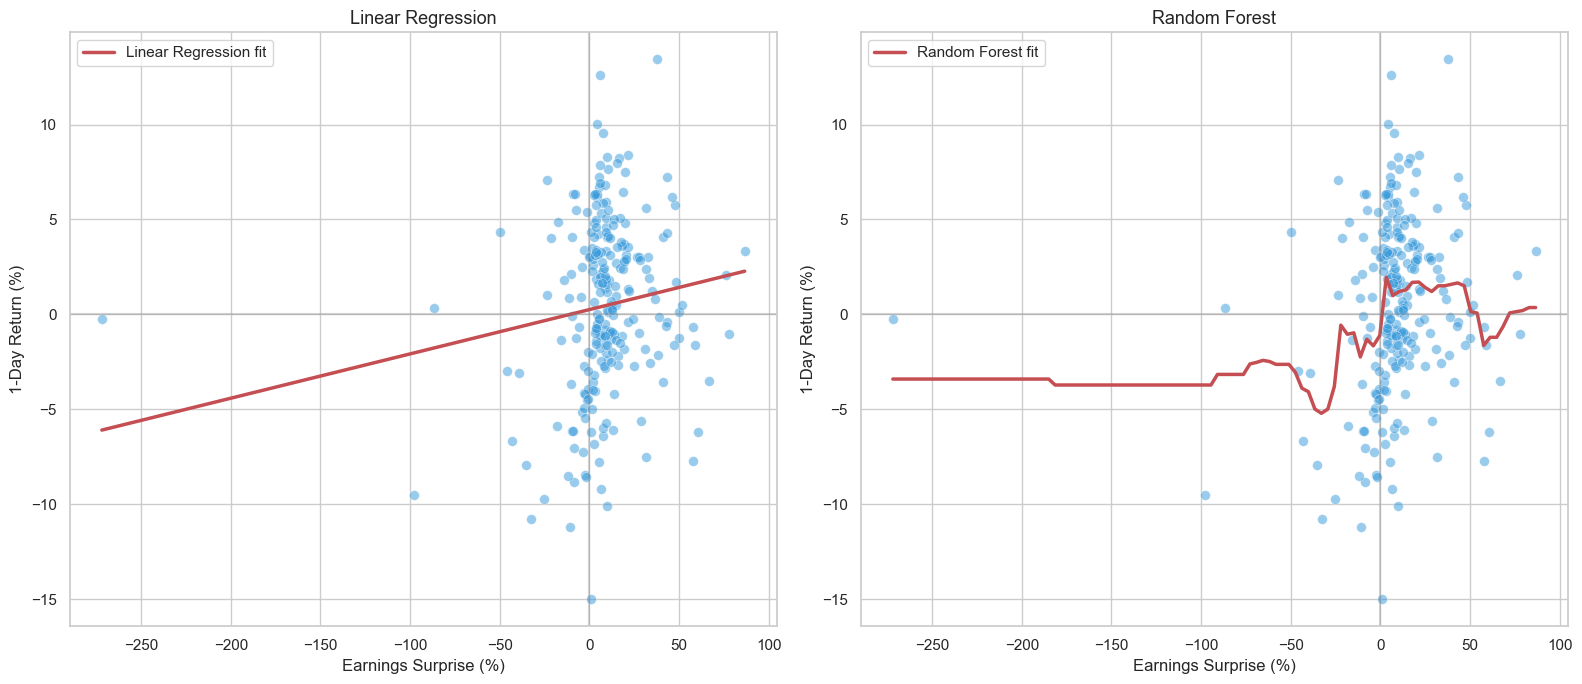

Chart saved: model_comparison.png


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error

# Prepare features for earnings events
model_df = earnings_returns[['Ticker', 'Surprise(%)', 'Day_1']].dropna().copy()

if len(model_df) > 10:
    X = model_df[['Surprise(%)']].values
    y = model_df['Day_1'].values
    
    # Linear Regression
    lr = LinearRegression()
    lr_scores = cross_val_score(lr, X, y, cv=5, scoring='r2')
    lr.fit(X, y)
    
    # Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42)
    rf_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
    rf.fit(X, y)
    
    print("=" * 50)
    print("MODEL RESULTS: Predicting 1-Day Return from Earnings Surprise")
    print("=" * 50)
    print(f"\nSample size: {len(model_df)} earnings events")
    print(f"\nLinear Regression:")
    print(f"  Coefficient: {lr.coef_[0]:.4f} (a 1% surprise -> {lr.coef_[0]:.4f}% return)")
    print(f"  Intercept:   {lr.intercept_:.4f}")
    print(f"  Cross-val R2: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")
    print(f"\nRandom Forest:")
    print(f"  Cross-val R2: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
    
    # Plot model predictions vs actual
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    
    for i, (model, name) in enumerate([(lr, 'Linear Regression'), (rf, 'Random Forest')]):
        ax = axes[i]
        ax.scatter(X, y, alpha=0.5, s=50, color='#3498db', edgecolors='white', linewidth=0.5)
        ax.plot(x_range, model.predict(x_range), 'r-', linewidth=2.5, label=f'{name} fit')
        ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
        ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
        ax.set_xlabel('Earnings Surprise (%)', fontsize=12)
        ax.set_ylabel('1-Day Return (%)', fontsize=12)
        ax.set_title(f'{name}', fontsize=13)
        ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Chart saved: model_comparison.png")
else:
    print("Not enough data for modeling. Need at least 10 matched earnings events.")

## 7. Summary Statistics

In [16]:
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

# Earnings stats
if 'Day_1' in earnings_returns.columns:
    beats = earnings_returns[earnings_returns['Category'] == 'Beat (> 2%)']
    misses = earnings_returns[earnings_returns['Category'] == 'Miss (< -2%)']
    
    print(f"\n--- EARNINGS IMPACT ---")
    print(f"Total earnings events analyzed: {len(earnings_returns)}")
    if len(beats) > 0:
        print(f"Avg 1-day return after BEAT:  {beats['Day_1'].mean():+.2f}%")
    if len(misses) > 0:
        print(f"Avg 1-day return after MISS:  {misses['Day_1'].mean():+.2f}%")
    if len(beats) > 0 and len(misses) > 0:
        spread = beats['Day_1'].mean() - misses['Day_1'].mean()
        print(f"Beat-Miss spread:             {spread:.2f} percentage points")

# Analyst stats
if 'Day_1' in analyst_returns.columns:
    upgrades = analyst_returns[analyst_returns['Action'] == 'up']
    downgrades = analyst_returns[analyst_returns['Action'] == 'down']
    
    print(f"\n--- ANALYST RATING IMPACT ---")
    print(f"Total analyst actions analyzed: {len(analyst_returns)}")
    if len(upgrades) > 0:
        print(f"Avg 1-day return after UPGRADE:   {upgrades['Day_1'].mean():+.2f}%")
    if len(downgrades) > 0:
        print(f"Avg 1-day return after DOWNGRADE: {downgrades['Day_1'].mean():+.2f}%")

print(f"\n--- MODEL PERFORMANCE ---")
if len(model_df) > 10:
    print(f"Linear Regression R2: {lr_scores.mean():.4f}")
    print(f"Random Forest R2:     {rf_scores.mean():.4f}")
    print(f"\nInterpretation: R2 close to 0 means earnings surprise alone")
    print(f"doesn't explain most of the variance in returns. This is expected --")
    print(f"markets are complex. The DIRECTION is usually right, but the")
    print(f"MAGNITUDE is hard to predict.")

KEY FINDINGS

--- EARNINGS IMPACT ---
Total earnings events analyzed: 240
Avg 1-day return after BEAT:  +1.36%
Avg 1-day return after MISS:  -2.24%
Beat-Miss spread:             3.60 percentage points

--- ANALYST RATING IMPACT ---
Total analyst actions analyzed: 451
Avg 1-day return after UPGRADE:   +1.40%
Avg 1-day return after DOWNGRADE: -0.86%

--- MODEL PERFORMANCE ---
Linear Regression R2: 0.0074
Random Forest R2:     0.0256

Interpretation: R2 close to 0 means earnings surprise alone
doesn't explain most of the variance in returns. This is expected --
markets are complex. The DIRECTION is usually right, but the
MAGNITUDE is hard to predict.


## 8. Conclusions & Next Steps

### What We Found
This analysis measured how financial sector stocks react to two types of events:
earnings surprises and analyst rating changes. Key questions answered:

1. **Do earnings beats reliably lead to price increases?** 
   Check the charts above for the answer in this dataset.

2. **Which moves stocks more: earnings or analyst actions?** 
   The comparison chart in Section 5 shows the relative magnitude.

3. **Can we predict the size of the reaction?** 
   The simple models in Section 6 show how much (or little) predictive power
   the surprise percentage alone provides.

### Limitations
- **Survivorship bias**: We only look at currently listed companies
- **Confounding events**: Other news may coincide with earnings dates
- **Small sample**: ~25 quarters per company limits statistical power
- **No transaction costs**: Real trading would need to account for spreads and fees

### Next Steps (Future Phases)
- **Phase 2**: Automate data refresh with GitHub Actions (auto-update weekly)
- **Phase 3**: Build an interactive Streamlit dashboard
- **V2 Features**: Add news sentiment analysis, expand to more sectors,
  test more sophisticated models (XGBoost, multi-factor)

---
*Data source: Yahoo Finance via yfinance. For educational and research purposes only.
Not financial advice.*